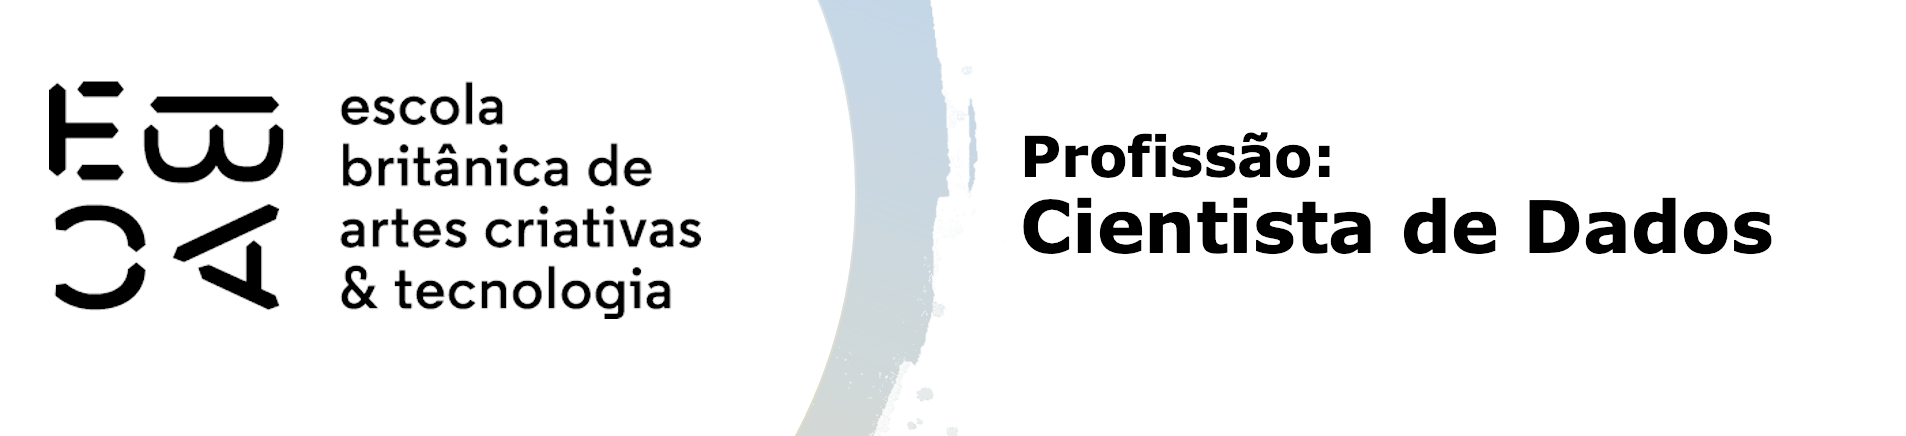

# Métodos hierárquicos de agrupamento - Tarefa

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import fetch_species_distributions
from sklearn.preprocessing import StandardScaler, LabelEncoder

import scipy.cluster.hierarchy as shc

## 1) Repetindo o que fizemos em aula

Primeiramente vamos repetir o que fizemos em aula com a base de pinguins.

1. Selecione as variáveis quantitativas da base de pinguins
2. Elimine valores faltantes
3. Padronize as variáveis para média zero e desvio padrão 1
4. Faça um agrupamento hierárquico dividindo essa base em 3 grupos
5. Faça o Dendrograma

In [21]:
peng = sns.load_dataset('penguins')
peng.index.name='id'
peng_num = peng.select_dtypes(include='number').dropna()

* removendo dados nulos das colunas

In [22]:
peng.dropna()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
id,,,,,,,
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male


verificando si tem valores ausentes nas colunas e fazendo a contagem

In [23]:
peng.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

preenchendo dados ausentes

In [24]:
peng.fillna(0)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
id,,,,,,,
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,0.0,0.0,0.0,0.0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,0.0,0.0,0.0,0.0,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male


## Padronização dos dados

Há várias formas de se fazer uma padronização dos dados, uma das mais populares é esta, que deixa a variável com média zero e desvio padrão 1.

In [25]:
padronizador = StandardScaler()
peng_pad = padronizador.fit_transform(peng_num)

Definir o objeto do agrupamento
Como em diversos procedimentos no Python / Scikit Learn, vamos definir um objeto da classe do agrupamento que queremos fazer - isso significa que ele vai ter os métodos e atributos convenientes para o nosso estudo. Vamos indicar neste passo também os parâmetros do algoritmo.

Como de costume, neste passo não colocamos os dados de entrada.

## Definir o objeto do agrupamento

Como em diversos procedimentos no Python / Scikit Learn, vamos definir um objeto da classe do agrupamento que queremos fazer - isso significa que ele vai ter os métodos e atributos convenientes para o nosso estudo. Vamos indicar neste passo também os parâmetros do algoritmo.

Como de costume, neste passo não colocamos os dados de entrada.

In [26]:
clus = AgglomerativeClustering(linkage="complete", 
                                 distance_threshold = None, 
                                 n_clusters=3)

## Treinar o algoritmo

Agora sim indicamos os dados, o algoritmo roda, e no objeto criado ficam as informações pertinentes, como por exemplo o rótulo dos grupos para cada linha do *data frame*..

In [27]:
clus.fit(peng_pad)

AgglomerativeClustering(linkage='complete', n_clusters=3)

In [28]:
peng_num['grupo'] = clus.labels_
peng_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,grupo
id,,,,,
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
4,36.7,19.3,193.0,3450.0,1
5,39.3,20.6,190.0,3650.0,1


Lembrando que removemos valores missing, o que tem impacto com a ordem das linhas da tabela. Assim, precisamos fazer um *left join* usando como chave o *index* da base original, o qual demos um nome logo que carregamos os dados, especialmente para poder executar este passo.

In [29]:
peng = peng.merge(peng_num['grupo'], how='left', on='id')

In [30]:
peng.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,grupo
id,,,,,,,,
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,1.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.0


## Visualização dos dados

O gráfico de dispersão nos mostra os dados que vamos ajustar, colorido pela espécie. Lembrando que embora as espécies mostrem agrupamentos naturais nessa base de dados, não queremos classificar os dados nas espécies, mas sim encontrar padrões naturais - que se coincidirem com as espécies será somente uma feliz coincidência.

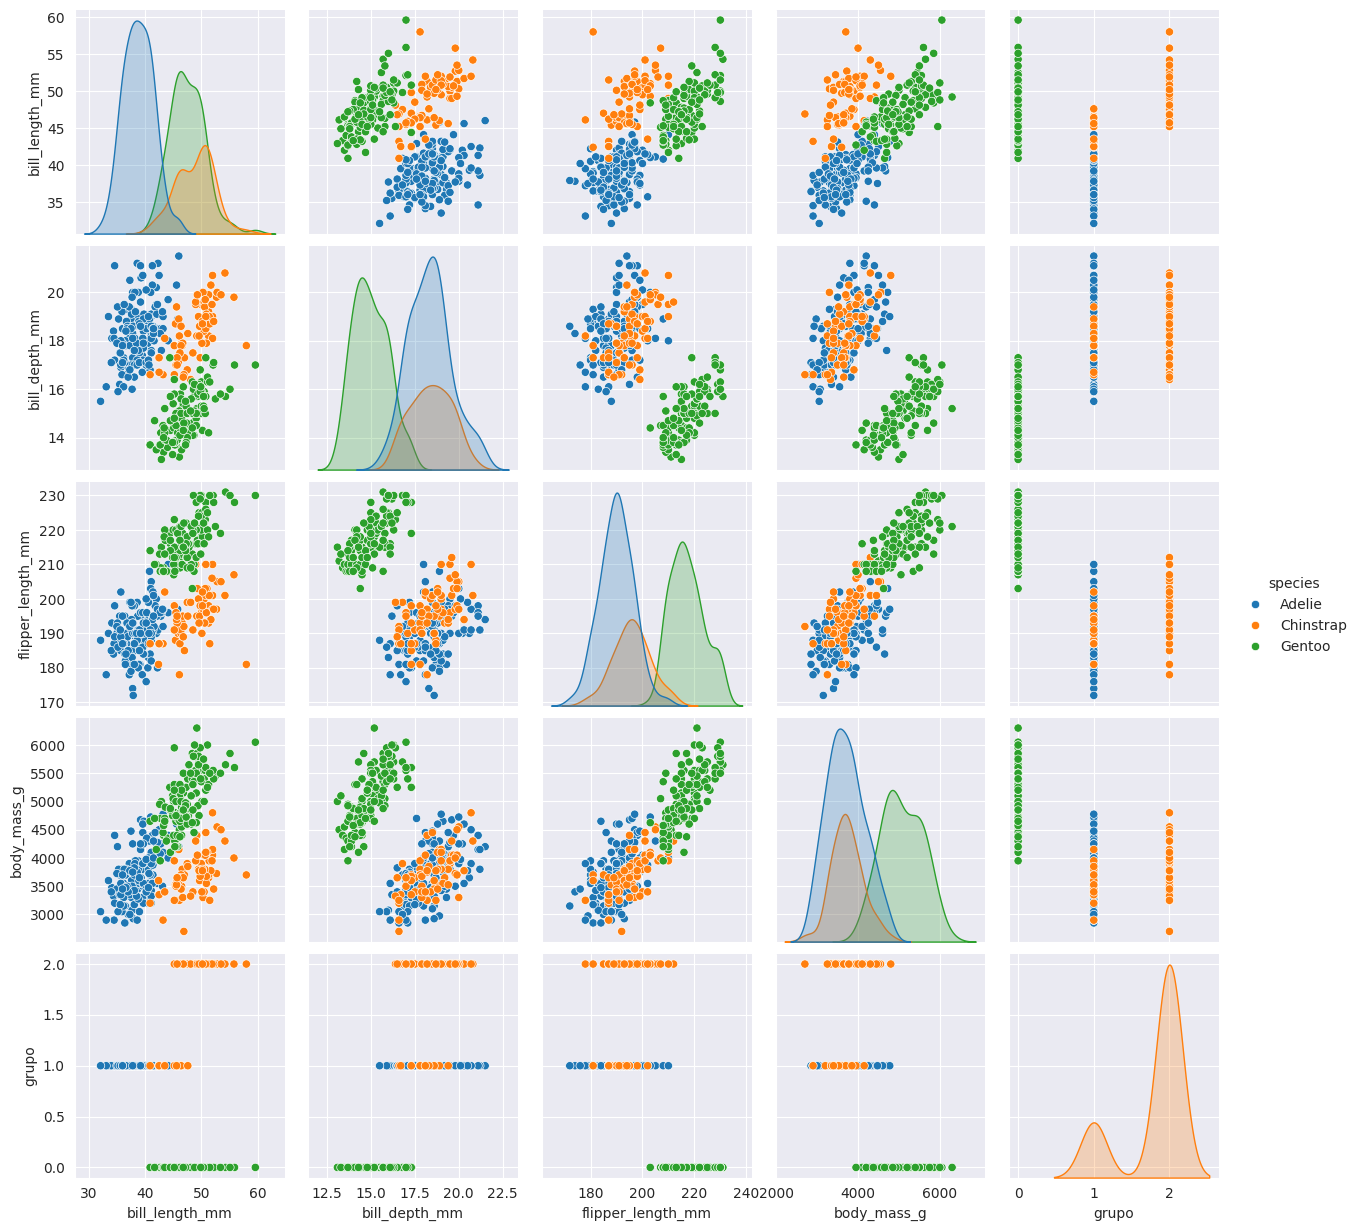

In [31]:
sns.pairplot(data=peng, hue='species')

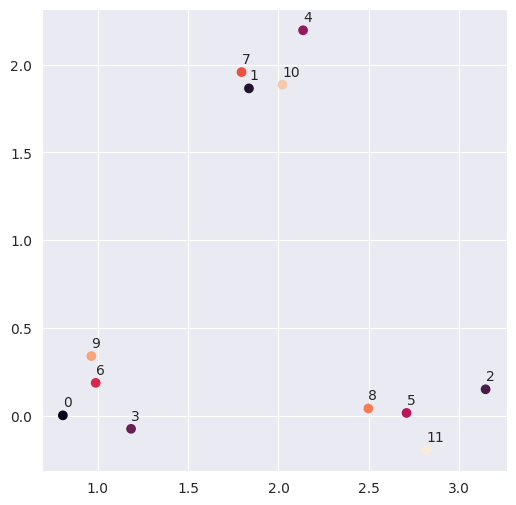

In [32]:
import numpy as np

## Gerar os dados
np.random.seed(2360873)
x = np.random.normal([1, 2, 3]*4,.2,12)
y = np.random.normal([0, 2, 0]*4,.2,12)
pontos = pd.DataFrame(np.c_[x,y], columns = ['x', 'y'])
pontos

# Fazer o gráfico
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1)

cores = pontos.index.values
ax.scatter(pontos['x'], pontos['y'], c=cores)

for idx, col in pontos.iterrows():
    ax.annotate(idx, (col['x'], col['y']+.05) )

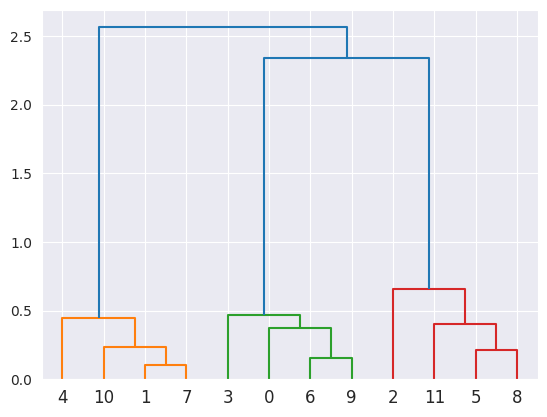

In [33]:
dend = shc.dendrogram(shc.linkage(pontos, method='complete'))

## 2) Avalie os grupos

Descreva os grupos:

- Quantos pinguins de cada espécie há em cada grupo?
- Descreva as variáveis quantitativas de cada grupo com as técnicas que você preferir.

* a especie chinstrap no grupo laranja tem 22 pinguins
* ja a especie gentoo tem 18 pinguins
* ja especie adelie 25 pinguins

* no grupo chinstrap tem 8 pinguins
* no gentoo tem 15 pinguins
* e no grupo adeli 12 pinguins

## 3) Alterando o agrupamento

O Dendrogarma sugere que podemem haver grupos interessantes se solicitarmos mais que 3 grupos. Se quisermos testar o agrupamento com mais de 3 grupos, quantos grupos o Dendrograma te sugere? (Dica: não faça mais que 6 grupos).

- Faça o agrupamento hierárquico semelhante ao anterior, mas com o número de grupos que você escolheu.
- Analise esses agrupamentos
    - Quantos pinguins de cada espécie há em cada grupo?
    - Quantos pinguins de cada espécie machos e fêmeas há em cada grupo?
- Na sua opinião, o agrupamento capturou algum padrão natural dos dados? Qual?

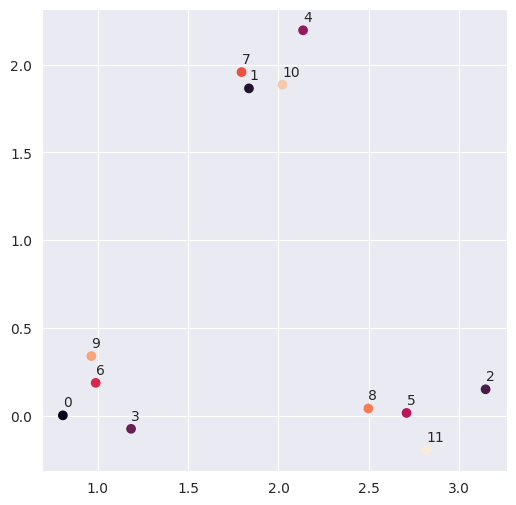

In [34]:
# Fazer o gráfico
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1)

cores = pontos.index.values
ax.scatter(pontos['x'], pontos['y'], c=cores)

for idx, col in pontos.iterrows():
    ax.annotate(idx, (col['x'], col['y']+.05) )

A imagem mostra um gráfico de dispersão com pontos numerados e coloridos, indicando diferentes
agrupamentos. Parece que os pontos estão distribuídos em algumas regiões mais concentradas,
sugerindo a presença de clusters. Além disso, há alguns pontos mais isolados, que podem ser outliers.
De maneira geral, os grupos estão bem separados, o que pode indicar um bom agrupamento.


pela analise acima
* no grupo chinstrap tem 15 pinguins
* no gentoo tem 13 pinguins
* e no grupo adeli 8 pinguins

In [35]:
# Contar pinguins por espécie, sexo e grupo
result = peng.groupby(['species', 'sex', 'grupo']).size().reset_index(name='count')

# Imprimir o resultado
print(result)


     species     sex  grupo  count
0     Adelie  Female    1.0     73
1     Adelie    Male    1.0     73
2  Chinstrap  Female    1.0     14
3  Chinstrap  Female    2.0     20
4  Chinstrap    Male    2.0     34
5     Gentoo  Female    0.0     58
6     Gentoo    Male    0.0     61


O agrupamento não apresentou uma diferença significativa na quantidade total de pinguins.
Ao comparar os sexos, foram contabilizados 168 pinguins machos e 166 pinguins fêmeas. Isso
representa um aumento de aproximadamente 0,03% na quantidade de machos em relação às fêmeas.
